**Care Transition Efficiency and Placement Outcome Analytics**

In [1]:
from google.colab import files
import pandas as pd
uploaded=files.upload()
data=pd.read_csv("HHS_Unaccompanied_Alien_Children_Program(1).csv")
df=pd.DataFrame(data)

Saving HHS_Unaccompanied_Alien_Children_Program(1).csv to HHS_Unaccompanied_Alien_Children_Program(1).csv


In [35]:
df.head()
df.tail()
df.columns
df.dtypes
df.info()
df.shape
df=df[df['Date']!=0]
df['Date']=pd.to_datetime(df['Date'])
df.describe()
df=df.sort_values(by="Date")
df=df.reset_index(drop=True)
df.head(7)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 11 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[ns]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   Children in CBP custody                          720 non-null    float64       
 3   Children transferred out of CBP custody          720 non-null    float64       
 4   Children in HHS Care                             720 non-null    float64       
 5   Children discharged from HHS Care                720 non-null    float64       
 6   Transfer_Efficiency                              720 non-null    float64       
 7   Discharge_Effectiveness                          720 non-null    float64       
 8   Throughput                              

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Transfer_Efficiency,Discharge_Effectiveness,Throughput,Backlog,outcome_stability
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0,0.641509,0.066403,13.212121,6130.0,0.000000
1,2023-01-22,32.0,49.0,39.0,7122.0,227.0,0.795918,0.031873,7.093750,6895.0,0.000000
2,2023-01-23,32.0,50.0,39.0,7280.0,181.0,0.780000,0.024863,5.656250,7099.0,0.000000
3,2023-01-24,47.0,42.0,47.0,7433.0,175.0,1.119048,0.023544,3.723404,7258.0,0.000000
4,2023-01-25,20.0,22.0,41.0,7538.0,180.0,1.863636,0.023879,9.000000,7358.0,0.000000
5,2023-01-29,23.0,45.0,11.0,7472.0,303.0,0.244444,0.040551,13.173913,7169.0,0.000000
6,2023-01-30,34.0,54.0,29.0,7743.0,196.0,0.537037,0.025313,5.764706,7547.0,96.393045


In [41]:
df.isnull().sum()
df.duplicated().unique()
df.fillna(0,inplace=True)
df.isnull().sum()
df=df.drop_duplicates()
df.duplicated().unique()
df['Children in HHS Care']=df["Children in HHS Care"].astype("str").str.replace(",","")
df['Children in HHS Care']=df['Children in HHS Care'].astype("float")
df.dtypes
df['Transfer_Efficiency']=df['Children transferred out of CBP custody']/df['Children in CBP custody']
df['Discharge_Effectiveness']=df['Children discharged from HHS Care']/df['Children in HHS Care']
df['Throughput']=df['Children discharged from HHS Care']/df['Children apprehended and placed in CBP custody*']
df['Backlog']=df['Children in HHS Care']-df['Children discharged from HHS Care']
df['outcome_stability']=df['Children discharged from HHS Care'].rolling(7).std()
df.fillna(0,inplace=True)
df.head(7)


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Transfer_Efficiency,Discharge_Effectiveness,Throughput,Backlog,outcome_stability
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0,0.641509,0.066403,13.212121,6130.0,0.000000
1,2023-01-22,32.0,49.0,39.0,7122.0,227.0,0.795918,0.031873,7.093750,6895.0,0.000000
2,2023-01-23,32.0,50.0,39.0,7280.0,181.0,0.780000,0.024863,5.656250,7099.0,0.000000
3,2023-01-24,47.0,42.0,47.0,7433.0,175.0,1.119048,0.023544,3.723404,7258.0,0.000000
4,2023-01-25,20.0,22.0,41.0,7538.0,180.0,1.863636,0.023879,9.000000,7358.0,0.000000
5,2023-01-29,23.0,45.0,11.0,7472.0,303.0,0.244444,0.040551,13.173913,7169.0,0.000000
6,2023-01-30,34.0,54.0,29.0,7743.0,196.0,0.537037,0.025313,5.764706,7547.0,96.393045


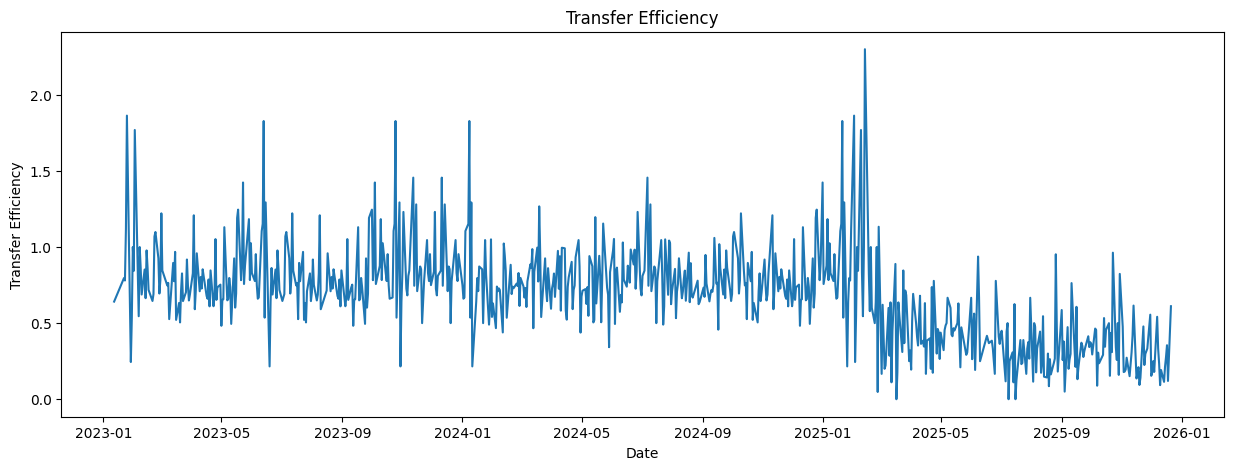

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,5))

plt.plot(df['Date'],df['Transfer_Efficiency'])
plt.title("Transfer Efficiency")
plt.xlabel("Date")
plt.ylabel("Transfer Efficiency")
plt.show()


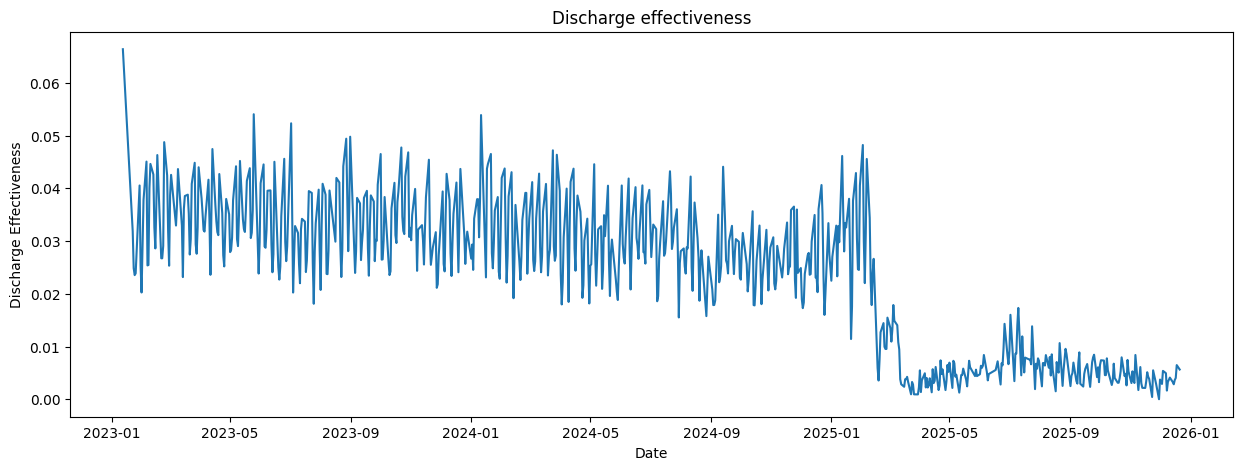

In [44]:
#discharge effectiveness
plt.figure(figsize=(15,5))
plt.plot(df['Date'],df["Discharge_Effectiveness"])
plt.title("Discharge effectiveness")
plt.xlabel("Date")
plt.ylabel("Discharge Effectiveness")
plt.show()

[]

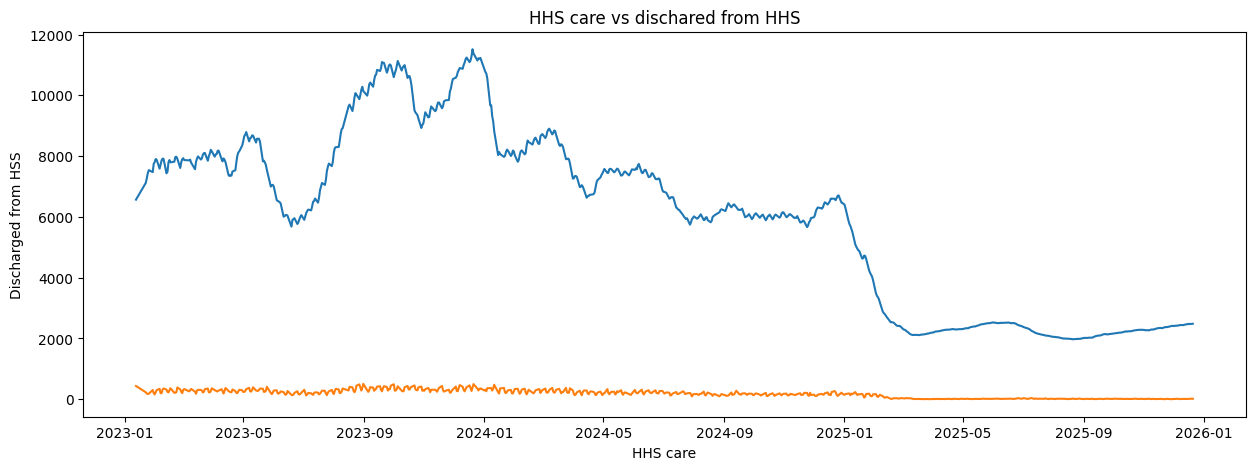

In [ ]:
#HHS care vs discharged
plt.figure(figsize=(15,5))
plt.plot(ddf['Date'],df['Children discharged from HHS Care'],label="discharged")
plt.title